In [1]:
#Preamble
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math
import os

# Get NIST data

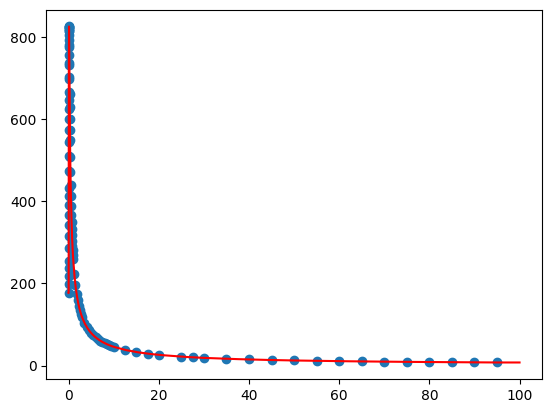

In [2]:
#Load in NIST SP data for protons
data = pd.read_csv(r"..\TOPAS_data\NIST stopping power.csv", sep='|',header=None)

SPdata = pd.DataFrame(columns=['Energy', 'SP', 'CSDA'])
SPdata['Energy'] = data.iloc[:,0]
SPdata['SP'] = data.iloc[:,1]
SPdata['CSDA'] = data.iloc[:,2]
SPdata = SPdata[SPdata['Energy']<100]

#interpolate data down to 4 digits
Expanded_SP = pd.DataFrame(columns=['Energy', 'SP', 'CSDA'])
Expanded_SP['Energy'] = np.arange(0, 100, 0.0001)
Expanded_SP['SP'] = np.interp(Expanded_SP['Energy'], SPdata['Energy'], SPdata['SP'])
Expanded_SP['CSDA'] = np.interp(Expanded_SP['Energy'], SPdata['Energy'], SPdata['CSDA'])

plt.scatter(SPdata['Energy'], SPdata['SP'], label='NIST data')
plt.plot(Expanded_SP['Energy'], Expanded_SP['SP'], label='Interpolation', color='r')

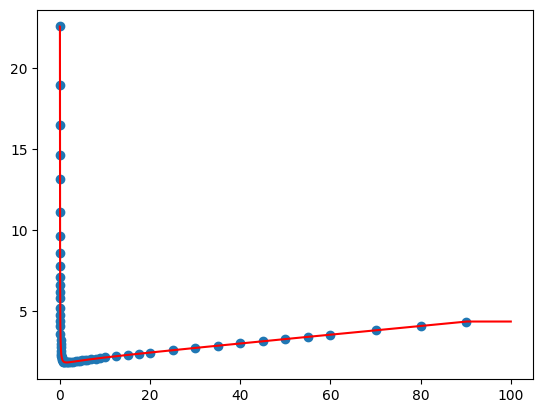

In [3]:
#Load in NIST SP data for electrons
data = pd.read_csv(r"..\TOPAS_data\NIST stopping power electrons.csv", sep='|',header=None)

SPdata = pd.DataFrame(columns=['Energy', 'SP', 'CSDA'])
SPdata['Energy'] = data.iloc[:,0]
SPdata['SP'] = data.iloc[:,1]
SPdata = SPdata[SPdata['Energy']<100]

#interpolate data down to 4 digits
Expanded_SP_el = pd.DataFrame(columns=['Energy', 'SP', 'CSDA'])
Expanded_SP_el['Energy'] = np.arange(0, 100, 0.0001)
Expanded_SP_el['SP'] = np.interp(Expanded_SP['Energy'], SPdata['Energy'], SPdata['SP'])

plt.scatter(SPdata['Energy'], SPdata['SP'], label='NIST data')
plt.plot(Expanded_SP_el['Energy'], Expanded_SP_el['SP'], label='Interpolation', color='r')

# LET and dose statistics

In [4]:
def Calculate_LET_from_phsp(phsp_path, NIST_data, NIST_data_el):
    try:
        #Read in phsp file
        d = pd.read_csv(phsp_path, header=None, sep='\s+')

        #Select protons
        d_p = d.loc[d.iloc[:,7]==2212]
        d_p.reset_index(inplace=True)

        proton_data = pd.DataFrame(columns=['Energy', 'Weight', 'LET'])
        proton_data['Energy'] = d_p.iloc[:,6]
        proton_data['Weight'] = d_p.iloc[:,7]

        #Look up stopping power for each kinetic energy
        for i in range(len(proton_data)):
            en = proton_data.loc[i, 'Energy']

            sp = NIST_data[round(NIST_data['Energy'],4)==round(en,4)]
            
            #convert to LET
            proton_data.loc[i, 'LET'] = np.array(sp['SP']/10)[0]


        #Select electrons
        d_e = d.loc[d.iloc[:,7]==11]
        d_e.reset_index(inplace=True)

        el_data = pd.DataFrame(columns=['Energy', 'Weight', 'LET'])
        el_data['Energy'] = d_e.iloc[:,6]
        el_data['Weight'] = d_e.iloc[:,7]
        

        #Look up stopping power for each kinetic energy
        for i in range(len(el_data)):
            en = float(el_data.loc[i, 'Energy'])

            sp = NIST_data_el[round(NIST_data_el['Energy'],4)==round(en,4)]
            
            #convert to LET
            el_data.loc[i, 'LET'] = np.array(sp['SP']/10)[0]
        
        particle_data = pd.concat([proton_data, el_data])

        particle_data['Dose_weights'] = particle_data['Weight']*particle_data['LET']
        particle_data['Dose_weights'] = particle_data['Dose_weights']/particle_data['Dose_weights'].sum()
        particle_data['LET_d'] = particle_data['Dose_weights']*particle_data['LET']

        LET = round(particle_data['LET_d'].sum(),2)
        
        
    except pd.errors.EmptyDataError:
        print('No histories for ' + phsp_path)

        LET = 0

    #print(phsp_path + ' finished')

    return LET

<>:4: SyntaxWarning: invalid escape sequence '\s'
<>:4: SyntaxWarning: invalid escape sequence '\s'
C:\Users\linux\AppData\Local\Temp\ipykernel_28896\3984868068.py:4: SyntaxWarning: invalid escape sequence '\s'
  d = pd.read_csv(phsp_path, header=None, sep='\s+')


In [5]:
# print('---low LET---')

# let_cells = pd.read_csv(r"..\TOPAS_data\OUTPUTS_PHYSICS_LOW\Setup_low_CellLayer_LET.csv", skiprows=4)
# let_cells = let_cells['# ProtonLET ( MeV/mm/(g/cm3) ) : Sum   '][0]/10
# print('LET (scorer): ' + str(round(let_cells,2)) + ' keV/um')

# let_phsp = Calculate_LET_from_phsp(r"..\TOPAS_data\OUTPUTS_PHYSICS_LOW\Setup_low_CellLayer.phsp", Expanded_SP, Expanded_SP_el)
# print('LET (phsp): ' + str(round(let_phsp,2)) + ' keV/um')

# dose_cells = pd.read_csv(r"..\TOPAS_data\OUTPUTS_PHYSICS_LOW\Setup_low_CellLayer_Dose.csv", skiprows=4)
# print('Dose: ' + str(dose_cells['# DoseToWater ( Gy ) : Sum   '][0]) + ' Gy')

# print('---mid LET---')

# let_cells = pd.read_csv(r"..\TOPAS_data\OUTPUTS_PHYSICS_MID\Setup_high_CellLayer_LET.csv", skiprows=4)
# let_cells = let_cells['# ProtonLET ( MeV/mm/(g/cm3) ) : Sum   '][0]/10
# print('LET (scorer): ' + str(round(let_cells,2)) + ' keV/um')

# let_phsp = Calculate_LET_from_phsp(r"..\TOPAS_data\OUTPUTS_PHYSICS_MID\Setup_high_CellLayer.phsp", Expanded_SP, Expanded_SP_el)
# print('LET (phsp): ' + str(round(let_phsp,2)) + ' keV/um')

# dose_cells = pd.read_csv(r"..\TOPAS_data\OUTPUTS_PHYSICS_MID\Setup_high_CellLayer_Dose.csv", skiprows=4)
# print('Dose: ' + str(dose_cells['# DoseToWater ( Gy ) : Sum   '][0]) + ' Gy')

# print('---high LET---')

# let_cells = pd.read_csv(r"..\TOPAS_data\OUTPUTS_PHYSICS_HIGH\Setup_high_CellLayer_LET.csv", skiprows=4)
# let_cells = let_cells['# ProtonLET ( MeV/mm/(g/cm3) ) : Sum   '][0]/10
# print('LET (scorer): ' + str(round(let_cells,2)) + ' keV/um')

# let_phsp = Calculate_LET_from_phsp(r"..\TOPAS_data\OUTPUTS_PHYSICS_HIGH\Setup_high_CellLayer.phsp", Expanded_SP, Expanded_SP_el)
# print('LET (phsp): ' + str(round(let_phsp,2)) + ' keV/um')

# dose_cells = pd.read_csv(r"..\TOPAS_data\OUTPUTS_PHYSICS_HIGH\Setup_high_CellLayer_Dose.csv", skiprows=4)
# print('Dose: ' + str(dose_cells['# DoseToWater ( Gy ) : Sum   '][0]) + ' Gy')

# Analysis of lineal energy spectra

In [28]:
def read_in_spectrum(masterfolder):
    batches = [name for name in os.listdir(masterfolder)]
    count = 0
    ydata = pd.DataFrame(columns=['y', 'fy', 'yfy', 'dy', 'ydy'])
    i=0

    for batch in batches:
        path = os.path.join(masterfolder, batch, 'ySpecfile.txt')

        #update particle count
        phsp_path = os.path.join(masterfolder, batch, 'MONASScorer.phsp')
        print(phsp_path)
        try:
            count = count + len(pd.read_csv(phsp_path, header=None, sep='\s+'))
        except:
            continue

        #read in yspec file
        try:
            y = pd.read_csv(path, skiprows=1, header=None, sep='\s+')
            
            if i==0:
                ydata['y'] = y.iloc[:,0]
                ydata['fy'] = y.iloc[:,1]
                ydata['yfy'] = y.iloc[:,3]
                ydata['dy'] = y.iloc[:,5]
                ydata['ydy'] = y.iloc[:,7]
            
            else:
                ydata['fy'] = ydata['fy'].to_numpy() + y.iloc[:,1].to_numpy()
                ydata['yfy'] = ydata['yfy'] + y.iloc[:,3]
                ydata['dy'] = ydata['dy'] + y.iloc[:,5]
                ydata['ydy'] = ydata['ydy'] + y.iloc[:,7]
            
            i += 1

        except FileNotFoundError:
            continue


    print(str(i) + ' out of ' + str(len(batches)) + ' batches had particle data')
    print('Number of particles: ' + str(count))

    return ydata

<>:14: SyntaxWarning: invalid escape sequence '\s'
<>:20: SyntaxWarning: invalid escape sequence '\s'
<>:14: SyntaxWarning: invalid escape sequence '\s'
<>:20: SyntaxWarning: invalid escape sequence '\s'
C:\Users\linux\AppData\Local\Temp\ipykernel_28896\2517865682.py:14: SyntaxWarning: invalid escape sequence '\s'
  count = count + len(pd.read_csv(phsp_path, header=None, sep='\s+'))
C:\Users\linux\AppData\Local\Temp\ipykernel_28896\2517865682.py:20: SyntaxWarning: invalid escape sequence '\s'
  y = pd.read_csv(path, skiprows=1, header=None, sep='\s+')


In [7]:
ylow = read_in_spectrum(r"..\TOPAS_data\OUTPUTS_MONAS_LOW")
ymid1 = read_in_spectrum(r"..\TOPAS_data\OUTPUTS_MONAS_MID1")
ymid2 = read_in_spectrum(r"..\TOPAS_data\OUTPUTS_MONAS_MID2")
ymid3 = read_in_spectrum(r"..\TOPAS_data\OUTPUTS_MONAS_MID3")
ymid4 = read_in_spectrum(r"..\TOPAS_data\OUTPUTS_MONAS_MID4")
ymid5 = read_in_spectrum(r"..\TOPAS_data\OUTPUTS_MONAS_MID5")
ymid6 = read_in_spectrum(r"..\TOPAS_data\OUTPUTS_MONAS_MID6")
ymid7 = read_in_spectrum(r"..\TOPAS_data\OUTPUTS_MONAS_MID7")

ymid = (ymid1 + ymid2 + ymid3 + ymid4 + ymid5 + ymid6 + ymid7)/7

..\TOPAS_data\OUTPUTS_MONAS_LOW\Batch10\MONASScorer.phsp
..\TOPAS_data\OUTPUTS_MONAS_LOW\Batch3\MONASScorer.phsp
..\TOPAS_data\OUTPUTS_MONAS_LOW\Batch4\MONASScorer.phsp
..\TOPAS_data\OUTPUTS_MONAS_LOW\Batch9\MONASScorer.phsp
4 out of 10 batches had particle data
Number of particles: 1144
..\TOPAS_data\OUTPUTS_MONAS_MID1\Batch1\MONASScorer.phsp
..\TOPAS_data\OUTPUTS_MONAS_MID1\Batch10\MONASScorer.phsp
..\TOPAS_data\OUTPUTS_MONAS_MID1\Batch2\MONASScorer.phsp
..\TOPAS_data\OUTPUTS_MONAS_MID1\Batch5\MONASScorer.phsp
..\TOPAS_data\OUTPUTS_MONAS_MID1\Batch6\MONASScorer.phsp
..\TOPAS_data\OUTPUTS_MONAS_MID1\Batch7\MONASScorer.phsp
..\TOPAS_data\OUTPUTS_MONAS_MID1\Batch8\MONASScorer.phsp
..\TOPAS_data\OUTPUTS_MONAS_MID1\Batch9\MONASScorer.phsp
8 out of 10 batches had particle data
Number of particles: 125
..\TOPAS_data\OUTPUTS_MONAS_MID2\Batch1\MONASScorer.phsp
..\TOPAS_data\OUTPUTS_MONAS_MID2\Batch10\MONASScorer.phsp
..\TOPAS_data\OUTPUTS_MONAS_MID2\Batch2\MONASScorer.phsp
..\TOPAS_data\OUTPU

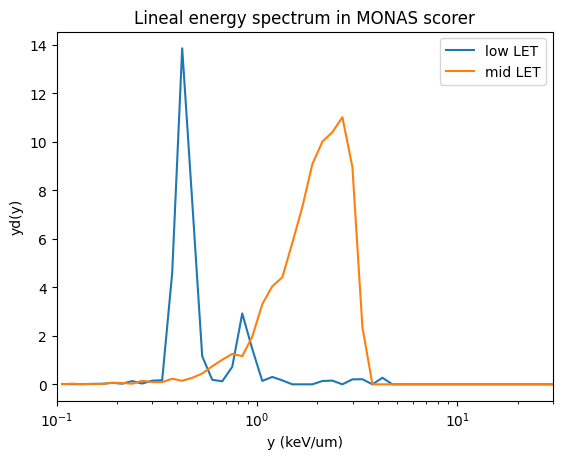

In [8]:
plt.plot(ylow['y'], ylow['ydy'], label='low LET')
plt.plot(ymid['y'], ymid['ydy'], label='mid LET')
plt.xscale('log')
plt.xlim([0.1,30])
plt.xlabel('y (keV/um)')
plt.ylabel('yd(y)')
plt.title('Lineal energy spectrum in MONAS scorer')
plt.legend()

# Calculating survival and RBE from y spectra

In [9]:
def spectrum_calc(spectrumfile):

    #constants
    y0 = 150
    #cell constants taken from HSG paper for now
    a0 = 0.317
    b = 0.057
    aR = 0.241
    Rd = 0.44
    rho = 1

    #parameters from yspecfile
    y = spectrumfile['y']
    fy = spectrumfile['dy']
    yfy = spectrumfile['ydy']

    #calculate bin widths
    ybins = np.zeros(len(y))
    for i in range(len(y)-1):
        if i == (len(y)-1):
            y[i] = 0
        else:
            ybins[i] = y[i+1] - y[i]

    #calculate ystar
    ystar_nominator = np.square(y0)*np.sum((1-np.exp(-(np.square(y))/np.square(y0)))*fy*ybins)
    ystar_denominator = np.sum(yfy*ybins)
    ystar = ystar_nominator/ystar_denominator

    #calculate survival and RBE data per dose
    data = pd.DataFrame(columns=['Dose', 'S', 'RBE'])
    doses = np.arange(0, 8, 0.1)
    for d in doses:
        newrow = {}
        newrow['Dose'] = d

        #calculate survival
        exponent = -(a0 + ((b)/(rho*math.pi*np.square(Rd)))*ystar)*d - b*np.square(d)
        newrow['S'] = np.exp(exponent)

        #calculate RBE
        RBE_nominator = np.sqrt(np.square(aR) - 4*b*np.log(newrow['S'])) - aR
        RBE_denominator = 2*b*d
        newrow['RBE'] = RBE_nominator/RBE_denominator

        data = pd.concat([data, pd.DataFrame([newrow])])


    return data

In [10]:
low = spectrum_calc(ylow)

mid = spectrum_calc(ymid)

C:\Users\linux\AppData\Local\Temp\ipykernel_28896\1283163361.py:44: RuntimeWarning: invalid value encountered in scalar divide
  newrow['RBE'] = RBE_nominator/RBE_denominator
C:\Users\linux\AppData\Local\Temp\ipykernel_28896\1283163361.py:46: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  data = pd.concat([data, pd.DataFrame([newrow])])
C:\Users\linux\AppData\Local\Temp\ipykernel_28896\1283163361.py:44: RuntimeWarning: invalid value encountered in scalar divide
  newrow['RBE'] = RBE_nominator/RBE_denominator
C:\Users\linux\AppData\Local\Temp\ipykernel_28896\1283163361.py:46: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA colum

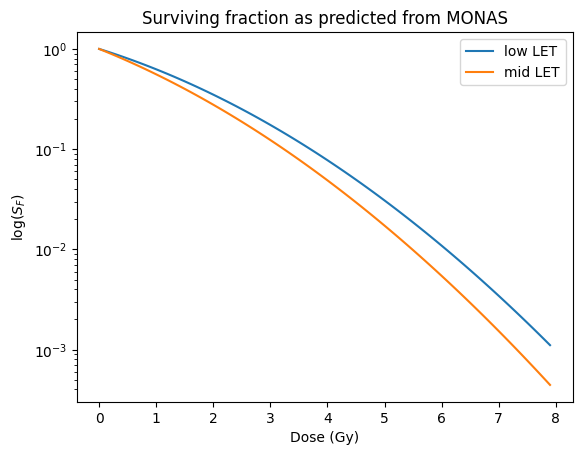

In [11]:
plt.plot(low['Dose'], low['S'], label='low LET')
plt.plot(mid['Dose'], mid['S'], label='mid LET')
plt.yscale('log')
plt.title('Surviving fraction as predicted from MONAS')
plt.xlabel('Dose (Gy)')
plt.ylabel('log($S_F$)')
plt.legend()

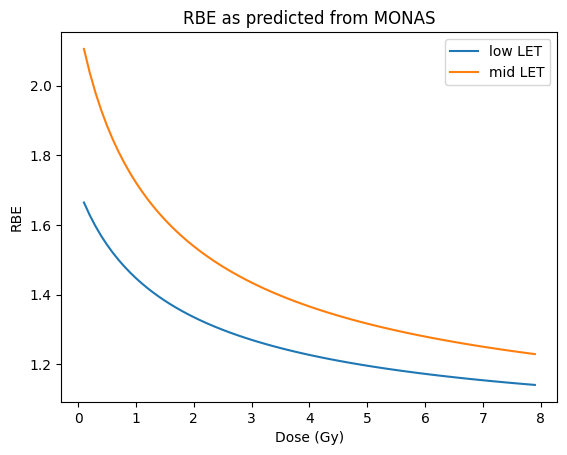

In [12]:
plt.plot(low['Dose'], low['RBE'], label='low LET')
plt.plot(mid['Dose'], mid['RBE'], label='mid LET')
plt.title('RBE as predicted from MONAS')
plt.xlabel('Dose (Gy)')
plt.ylabel('RBE')
plt.legend()

# TOPAS vs Rørvik predictions

In [13]:
def R_Func(X, a, b, c):
    d, l, dtwo = X
    return np.exp(-(a*d + b*l + c*dtwo))

In [14]:
def Calculate_RBE(d, let, p):

    if d == 0:
        RBE = float('nan')

    else:
        a_x = p[0]
        b_x = p[2]
        k = p[1]

        RBEmin = 1
        RBEmax = 1 + (k/a_x)*let
        A_B = a_x/b_x

        squareterm = np.square(A_B) + 4*d*A_B*RBEmax + 4*np.square(d)*np.square(RBEmin)
        RBE = (1/(2*d))*(np.sqrt(squareterm) - A_B)

    return RBE

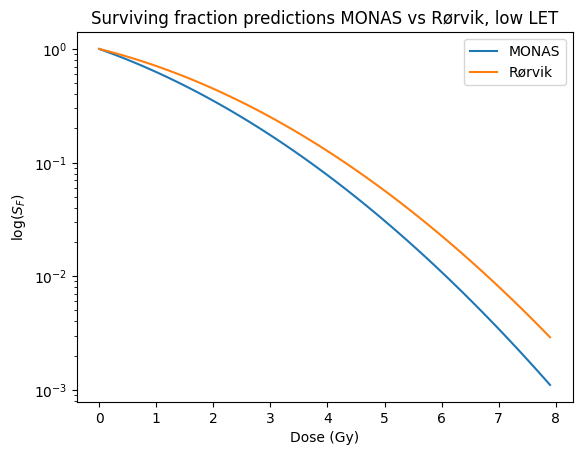

In [15]:
#low LET
d = np.arange(0, 8, 0.1)
x = (d, d*1.3, np.square(d))
S_rorvik = R_Func(x, 0.241, 0.037, 0.057)

plt.plot(low['Dose'], low['S'], label='MONAS')
plt.plot(d, S_rorvik, label='Rørvik')
plt.yscale('log')
plt.title('Surviving fraction predictions MONAS vs Rørvik, low LET')
plt.xlabel('Dose (Gy)')
plt.ylabel('log($S_F$)')
plt.legend()

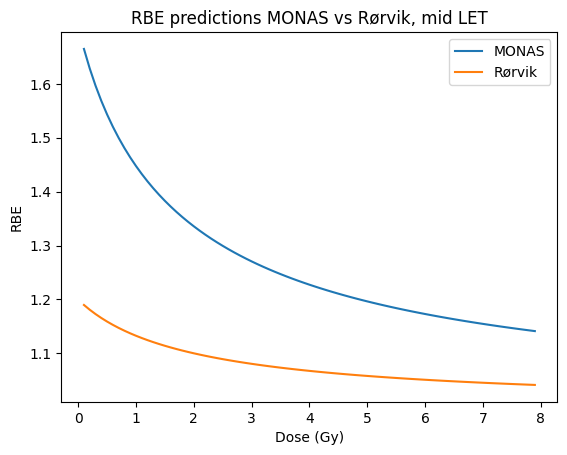

In [16]:
RBE_rorvik = np.zeros(len(d))
for i in range(len(d)):
    RBE_rorvik[i] = Calculate_RBE(d[i], 1.3, [0.241, 0.037, 0.057])

plt.plot(low['Dose'], low['RBE'], label='MONAS')
plt.plot(d, RBE_rorvik, label='Rørvik')
plt.title('RBE predictions MONAS vs Rørvik, mid LET')
plt.xlabel('Dose (Gy)')
plt.ylabel('RBE')
plt.legend()

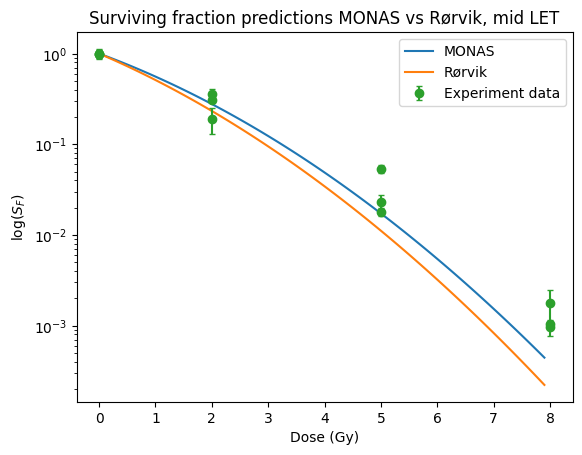

In [17]:
#mid LET
d = np.arange(0, 8, 0.1)
x = (d, d*10.1, np.square(d))
S_rorvik = R_Func(x, 0.241, 0.037, 0.057)

#data from experiments
PM_means = pd.read_excel('../Cell survival results/PM_means.xlsx')

plt.plot(mid['Dose'], mid['S'], label='MONAS')
plt.plot(d, S_rorvik, label='Rørvik')
plt.errorbar(PM_means['Dose'], PM_means['Mean Survival'], yerr=PM_means['STD'], fmt='o', capsize=2, label='Experiment data')
plt.yscale('log')
plt.title('Surviving fraction predictions MONAS vs Rørvik, mid LET')
plt.xlabel('Dose (Gy)')
plt.ylabel('log($S_F$)')
plt.legend()

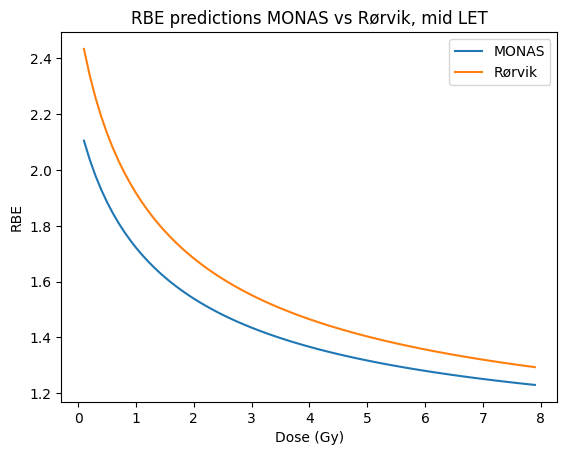

In [18]:
RBE_rorvik = np.zeros(len(d))
for i in range(len(d)):
    RBE_rorvik[i] = Calculate_RBE(d[i], 10.1, [0.241, 0.037, 0.057])

plt.plot(mid['Dose'], mid['RBE'], label='MONAS')
plt.plot(d, RBE_rorvik, label='Rørvik')
plt.title('RBE predictions MONAS vs Rørvik, mid LET')
plt.xlabel('Dose (Gy)')
plt.ylabel('RBE')
plt.legend()

# Let´s try for high

In [35]:
yhigh1 = read_in_spectrum(r"..\TOPAS_data\OUTPUTS_MONAS_HIGH1")

yhigh = yhigh1

..\TOPAS_data\OUTPUTS_MONAS_HIGH1\Batch1\MONASScorer.phsp
..\TOPAS_data\OUTPUTS_MONAS_HIGH1\Batch10\MONASScorer.phsp
..\TOPAS_data\OUTPUTS_MONAS_HIGH1\Batch2\MONASScorer.phsp
..\TOPAS_data\OUTPUTS_MONAS_HIGH1\Batch3\MONASScorer.phsp
..\TOPAS_data\OUTPUTS_MONAS_HIGH1\Batch4\MONASScorer.phsp
..\TOPAS_data\OUTPUTS_MONAS_HIGH1\Batch5\MONASScorer.phsp
..\TOPAS_data\OUTPUTS_MONAS_HIGH1\Batch6\MONASScorer.phsp
..\TOPAS_data\OUTPUTS_MONAS_HIGH1\Batch7\MONASScorer.phsp
..\TOPAS_data\OUTPUTS_MONAS_HIGH1\Batch8\MONASScorer.phsp
..\TOPAS_data\OUTPUTS_MONAS_HIGH1\Batch9\MONASScorer.phsp
6 out of 10 batches had particle data
Number of particles: 6


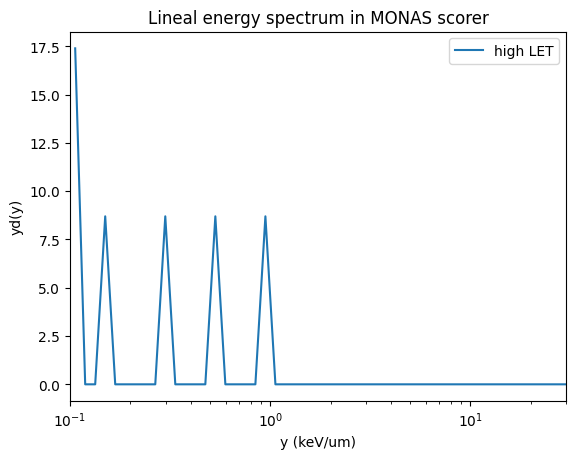

In [36]:
plt.plot(yhigh['y'], yhigh['ydy'], label='high LET')
plt.xscale('log')
plt.xlim([0.1,30])
plt.xlabel('y (keV/um)')
plt.ylabel('yd(y)')
plt.title('Lineal energy spectrum in MONAS scorer')
plt.legend()

In [37]:
high = spectrum_calc(yhigh)

C:\Users\linux\AppData\Local\Temp\ipykernel_28896\1283163361.py:44: RuntimeWarning: invalid value encountered in scalar divide
  newrow['RBE'] = RBE_nominator/RBE_denominator
C:\Users\linux\AppData\Local\Temp\ipykernel_28896\1283163361.py:46: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  data = pd.concat([data, pd.DataFrame([newrow])])


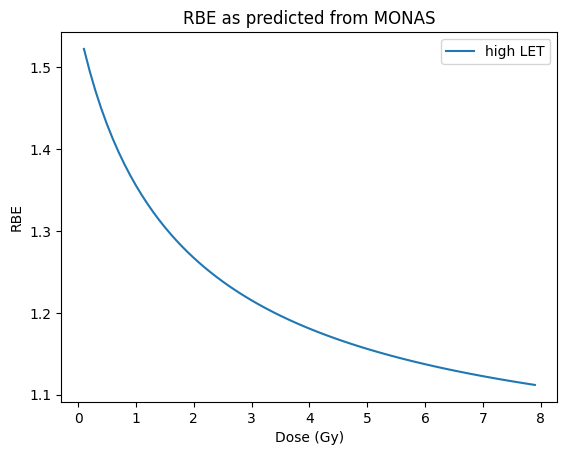

In [38]:
plt.plot(high['Dose'], high['RBE'], label='high LET')
plt.title('RBE as predicted from MONAS')
plt.xlabel('Dose (Gy)')
plt.ylabel('RBE')
plt.legend()